## 1. 서울시 중고등학교 데이터

### 1) 필요 라이브러리 설치

In [88]:
import pandas as pd
import numpy as np

### 1) 데이터 불러오기

df_mid: 서울시 중학교 기본정보.csv 
- 설명: 서울시에 존재하는 중학교에 대한 기본 정보 및 도로명 주소가 나와있는 데이터(후에 도로명 주소 가지고 위도 경도 변환)
- 출처: https://data.seoul.go.kr/dataList/OA-20556/S/1/datasetView.do
- 주요 컬럼: 학교종류명(중학교), 설립구분(사립/공립), 학교명, 관할조직명, 도로명주소

df_high: 서울시 고등학교 기본정보.csv
- 설명: 서울시에 존재하는 중학교에 대한 기본 정보 및 도로명 주소가 나와있는 데이터(후에 도로명 주소 가지고 위도 경도 변환)
- 출처: https://data.seoul.go.kr/dataList/OA-20557/S/1/datasetView.do
- 주요 컬럼: 학교종류명(고등학교), 설립구분(사립/공립), 학교명, 관할조직명, 도로명주소

df_open: 서울특별시교육청_민간개방 학교시설물현황_20250910.csv
- 설명: 서울시의 중/고등학교의 각 시설물(운동장, 체육관, 교실 등)에 대한 민간개방 여부가 나와있는 데이터
- 출처: https://www.data.go.kr/data/3078512/fileData.do
- 주요 컬럼: 시도교육청, 교육지원청, 지역, 학교명, 운동장개방여부

df_size: 2025년도 학교용지 현황(초/중/고)_서울특별시교육청.csv (초등학교, 중학교, 고등학교 데이터 따로 존재)
- 설명: 각 학교의 체육장 부지 및 타 학교와 공동사용 여부(초등학교와 공동사용하는 경우에는 제거)
- 출처: https://www.schoolinfo.go.kr/ng/go/pnnggo_a01_l2.do

In [89]:
# 서울시 중학교 기본정보(도로명 주소 포함)
df_mid = pd.read_csv('data/서울시 중학교 기본정보.csv', encoding='cp949')

# 서울시 고등학교 기본정보(도로명 주소 포함)
df_high = pd.read_csv('data/서울시 고등학교 기본정보.csv', encoding='cp949')

# 서울시 중고등학교 민간개방여부(도로명 주소 미포함)
df_open = pd.read_csv('data/서울특별시교육청_민간개방 학교시설물현황_20250910.csv', encoding='cp949')

### 2) df_mid 전처리

In [90]:
df_mid.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
1,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
2,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
3,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
4,중학교,사립,7134141,한양대학교사범대학부속중학교,Hanyang University Middle School,서울특별시성동광진교육지원청,4761,서울특별시 성동구 마조로 42,(사근동/한양사대부속중?고등학교),02-2200-3700,...,일반계,NaN,전기,주간,19600118,19600118,B10,서울특별시교육청,서울특별시,20230615


In [91]:
df_mid.info()

<class 'pandas.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   학교종류명        780 non-null    str    
 1   설립구분         780 non-null    str    
 2   표준학교코드       780 non-null    int64  
 3   학교명          780 non-null    str    
 4   영문학교명        780 non-null    str    
 5   관할조직명        780 non-null    str    
 6   도로명우편번호      780 non-null    int64  
 7   도로명주소        780 non-null    str    
 8   도로명상세주소      780 non-null    str    
 9   전화번호         780 non-null    str    
 10  홈페이지주소       780 non-null    str    
 11  팩스번호         780 non-null    str    
 12  남녀공학구분명      780 non-null    str    
 13  고등학교구분명      0 non-null      float64
 14  산업체특별학급존재여부  780 non-null    str    
 15  고등학교일반실업구분명  768 non-null    str    
 16  특수목적고등학교계열명  0 non-null      float64
 17  입시전후기구분명     780 non-null    str    
 18  주야구분명        780 non-null    str    
 19  설립일자         780 no

In [92]:
# df_mid 중복값 확인
print(df_mid.duplicated().sum())

390


In [93]:
# 중복값 제거
df_mid = df_mid.drop_duplicates(subset=['학교명'])
df_mid.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,중학교,사립,7134161,동국대학교사범대학부속가람중학교,Garam Middle School Attached to College of Edu...,서울특별시성동광진교육지원청,5038,서울특별시 광진구 광나루로36길 47,", 동국대학교사범대학부속가람중학교 (구의동)",02-6948-2280,...,일반계,NaN,전기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
2,중학교,공립,7134142,행당중학교,Haengdang Middle School,서울특별시성동광진교육지원청,4764,서울특별시 성동구 왕십리로 189,(행당동/행당중학교),02-2292-2721,...,일반계,NaN,전기,주간,19680806,19681002,B10,서울특별시교육청,서울특별시,20230615
4,중학교,사립,7134141,한양대학교사범대학부속중학교,Hanyang University Middle School,서울특별시성동광진교육지원청,4761,서울특별시 성동구 마조로 42,(사근동/한양사대부속중?고등학교),02-2200-3700,...,일반계,NaN,전기,주간,19600118,19600118,B10,서울특별시교육청,서울특별시,20230615
6,중학교,공립,7134140,자양중학교,Jayang Middle School,서울특별시성동광진교육지원청,5069,서울특별시 광진구 뚝섬로41길 33,(자양동/서울자양중학교),02-446-0365,...,일반계,NaN,전기,주간,19840301,19840301,B10,서울특별시교육청,서울특별시,20230615
8,중학교,공립,7134139,용곡중학교,Yong-gok Middle School,서울특별시성동광진교육지원청,4940,서울특별시 광진구 용마산로22길 76,(중곡동/용곡중학교),02-452-2622,...,일반계,NaN,전기,주간,19821209,19830504,B10,서울특별시교육청,서울특별시,20230615


In [94]:
# 학교 종류명, 설립구분, 학교명, 관할조직명, 도로명주소만 남기기
df_mid = df_mid[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소']]
df_mid.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47
2,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189
4,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42
6,중학교,공립,자양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로41길 33
8,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76


### 3) df_high 전처리

In [95]:
df_high.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,고등학교,사립,7011651,서울홍신고등학교,seoul-hongshin High School,서울특별시교육청,7638,서울특별시 강서구 강서로45길 70,"(내발산동, 서울홍신고등학교)",070-8644-6300,...,전문계,NaN,전기,주간,19870108,19870916,B10,서울특별시교육청,서울특별시,20240414
1,고등학교,사립,7011651,서울홍신고등학교,seoul-hongshin High School,서울특별시교육청,7638,서울특별시 강서구 강서로45길 70,"(내발산동, 서울홍신고등학교)",070-8644-6300,...,전문계,NaN,전기,주간,19870108,19870916,B10,서울특별시교육청,서울특별시,20240414
2,고등학교,사립,7011650,한양과학기술고등학교,Hanyang Science And Technology High School,서울특별시교육청,4566,서울특별시 중구 을지로 299,(신당동),02-2238-5181,...,전문계,NaN,전기,주간,19450901,19450901,B10,서울특별시교육청,서울특별시,20260329
3,고등학교,사립,7011650,한양과학기술고등학교,Hanyang Science And Technology High School,서울특별시교육청,4566,서울특별시 중구 을지로 299,(신당동),02-2238-5181,...,전문계,NaN,전기,주간,19450901,19450901,B10,서울특별시교육청,서울특별시,20260329
4,고등학교,공립,7011649,흑석고등학교,Heukseok High School,서울특별시교육청,6985,서울특별시 동작구 흑석한강로 36,(흑석동),02-399-9605,...,일반계,NaN,후기,주간,20260301,20260301,B10,서울특별시교육청,서울특별시,20260201


In [96]:
df_high.info()

<class 'pandas.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   학교종류명        638 non-null    str  
 1   설립구분         638 non-null    str  
 2   표준학교코드       638 non-null    int64
 3   학교명          638 non-null    str  
 4   영문학교명        638 non-null    str  
 5   관할조직명        638 non-null    str  
 6   도로명우편번호      638 non-null    int64
 7   도로명주소        638 non-null    str  
 8   도로명상세주소      638 non-null    str  
 9   전화번호         638 non-null    str  
 10  홈페이지주소       638 non-null    str  
 11  팩스번호         636 non-null    str  
 12  남녀공학구분명      638 non-null    str  
 13  고등학교구분명      638 non-null    str  
 14  산업체특별학급존재여부  638 non-null    str  
 15  고등학교일반실업구분명  638 non-null    str  
 16  특수목적고등학교계열명  42 non-null     str  
 17  입시전후기구분명     638 non-null    str  
 18  주야구분명        638 non-null    str  
 19  설립일자         638 non-null    int64
 20  개교기념일        638 non-

In [97]:
# df_high 중복값 확인
print(df_high.duplicated().sum())

319


In [98]:
# 중복값 제거
df_high = df_high.drop_duplicates(subset=['학교명'])
df_high.head()

,학교종류명,설립구분,표준학교코드,학교명,영문학교명,관할조직명,도로명우편번호,도로명주소,도로명상세주소,전화번호,...,고등학교일반실업구분명,특수목적고등학교계열명,입시전후기구분명,주야구분명,설립일자,개교기념일,시도교육청코드,시도교육청명,소재지명,적재일시
0,고등학교,사립,7011651,서울홍신고등학교,seoul-hongshin High School,서울특별시교육청,7638,서울특별시 강서구 강서로45길 70,"(내발산동, 서울홍신고등학교)",070-8644-6300,...,전문계,NaN,전기,주간,19870108,19870916,B10,서울특별시교육청,서울특별시,20240414
2,고등학교,사립,7011650,한양과학기술고등학교,Hanyang Science And Technology High School,서울특별시교육청,4566,서울특별시 중구 을지로 299,(신당동),02-2238-5181,...,전문계,NaN,전기,주간,19450901,19450901,B10,서울특별시교육청,서울특별시,20260329
4,고등학교,공립,7011649,흑석고등학교,Heukseok High School,서울특별시교육청,6985,서울특별시 동작구 흑석한강로 36,(흑석동),02-399-9605,...,일반계,NaN,후기,주간,20260301,20260301,B10,서울특별시교육청,서울특별시,20260201
6,고등학교,사립,7011586,동국대학교사범대학부속가람고등학교,Garam High School Attached To College Of Educa...,서울특별시교육청,5038,서울특별시 광진구 광나루로36길 47,동국대학교사범대학부속가람고등학교,0220491577,...,일반계,NaN,후기,주간,19300620,19300620,B10,서울특별시교육청,서울특별시,20250302
8,고등학교,공립,7011585,서울디지털콘텐츠고등학교,Seoul Digital Content High School,서울특별시교육청,7514,서울특별시 강서구 방화대로47길 9,"(방화동,서울디지털콘텐츠고등학교)",02-2666-2106,...,전문계,NaN,전기,주간,19940105,19940105,B10,서울특별시교육청,서울특별시,20230615


In [99]:
# 학교 종류명, 설립구분, 학교명, 관할조직명, 도로명주소만 남기기
df_high = df_high[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소']]
df_high.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소
0,고등학교,사립,서울홍신고등학교,서울특별시교육청,서울특별시 강서구 강서로45길 70
2,고등학교,사립,한양과학기술고등학교,서울특별시교육청,서울특별시 중구 을지로 299
4,고등학교,공립,흑석고등학교,서울특별시교육청,서울특별시 동작구 흑석한강로 36
6,고등학교,사립,동국대학교사범대학부속가람고등학교,서울특별시교육청,서울특별시 광진구 광나루로36길 47
8,고등학교,공립,서울디지털콘텐츠고등학교,서울특별시교육청,서울특별시 강서구 방화대로47길 9


### 4) df_mid, df_high 병합 → df_school 생성

In [100]:
# df_mid, df_high 합치기
df_school = pd.concat([df_mid, df_high], ignore_index=True)
df_school.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47
1,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189
2,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42
3,중학교,공립,자양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로41길 33
4,중학교,공립,용곡중학교,서울특별시성동광진교육지원청,서울특별시 광진구 용마산로22길 76


In [101]:
# 중학교 개수 세기
num_mid = df_school[df_school['학교종류명'] == '중학교'].shape[0]
print(f'서울시 중학교 개수: {num_mid}')
# 고등학교 개수 세기
num_high = df_school[df_school['학교종류명'] == '고등학교'].shape[0]
print(f'서울시 고등학교 개수: {num_high}')

서울시 중학교 개수: 390
서울시 고등학교 개수: 319


In [102]:
# 중학교 중 사립학교 개수 세기
num_mid_private = df_school[(df_school['학교종류명'] == '중학교') & (df_school['설립구분'] == '사립')].shape[0]
print(f'서울시 중학교 중 사립학교 개수: {num_mid_private}')
# 고등학교 중 사립학교 개수 세기
num_high_private = df_school[(df_school['학교종류명'] == '고등학교') & (df_school['설립구분'] == '사립')].shape[0]
print(f'서울시 고등학교 중 사립학교 개수: {num_high_private}')
# 중학교 중 공립학교 개수 세기

서울시 중학교 중 사립학교 개수: 109
서울시 고등학교 중 사립학교 개수: 200


### 5) df_open 전처리

In [103]:
df_open.head()

,시도교육청,교육지원청,지역,학교명,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부
0,서울특별시교육청,서울특별시교육청,송파구,가락고등학교,고,무,시설없음,무,시설없음,시설없음,시설없음,시설없음
1,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가락중학교,중,유,시설없음,무,유,시설없음,시설없음,시설없음
2,서울특별시교육청,서울특별시남부교육지원청,금천구,가산중학교,중,무,시설없음,유,시설없음,시설없음,시설없음,유
3,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가원중학교,중,유,시설없음,시설없음,시설없음,시설없음,시설없음,시설없음
4,서울특별시교육청,서울특별시교육청,서대문구,가재울고등학교,고,무,시설없음,시설없음,유,시설없음,시설없음,시설없음


In [104]:
df_open.head()

,시도교육청,교육지원청,지역,학교명,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부
0,서울특별시교육청,서울특별시교육청,송파구,가락고등학교,고,무,시설없음,무,시설없음,시설없음,시설없음,시설없음
1,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가락중학교,중,유,시설없음,무,유,시설없음,시설없음,시설없음
2,서울특별시교육청,서울특별시남부교육지원청,금천구,가산중학교,중,무,시설없음,유,시설없음,시설없음,시설없음,유
3,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가원중학교,중,유,시설없음,시설없음,시설없음,시설없음,시설없음,시설없음
4,서울특별시교육청,서울특별시교육청,서대문구,가재울고등학교,고,무,시설없음,시설없음,유,시설없음,시설없음,시설없음


In [105]:
# df_open 결측치 확인
print(df_open.isnull().sum())

시도교육청         0
교육지원청         0
지역            0
학교명           0
학교급코드         0
교실 개방여부       0
시청각실 개방여부     0
체육관 개방여부      0
운동장 개방여부      0
수영장 개방여부      0
테니스장 개방여부     0
잔디운동장 개방여부    0
dtype: int64


In [106]:
# df_open 중복값 확인
print(df_open.duplicated().sum())

0


In [107]:
# df_open에 들어있는 학교급 확인
print(df_open['학교급코드'].unique())

<StringArray>
['고', '중', '각종', '초', '특수']
Length: 5, dtype: str


In [108]:
# 고, 중만 추출
df_open = df_open[df_open['학교급코드'].isin(['고', '중'])]

### 3) df_school와 df_open의 차집합 구하기 
→ df_open에 있는데, df_school에 없는 학교 
- 금호여자중학교: 2024년부터 휴업하여 2026년부터 '금호중학교'로 교명을 바꾸어 재개교한 학교임
- 서울다솜관광고등학교: 대안 학교라 '학교알리미'에서는 '기타 학교'로 검색 결과가 나옴 => 해당 데이터에서는 포함 안 시킬 예정

In [109]:
# df_school와 df_open의 차집합 구하기
# df_mid의 학교명과 df_open의 학교명을 비교하여 df_school에만 있는 학교명 추출
school_only = df_school[~df_school['학교명'].isin(df_open['학교명'])]
# school_only의 학교명 출력
print('school_only에만 들어있는 학교명:\n', school_only['학교명'])
# df_school와 df_open의 교집합 구하기
school_intersection = df_school[df_school['학교명'].isin(df_open['학교명'])]
# mid_intersection의 학교명 출력
print(school_intersection['학교명'])
# df_open에만 있는 학교명 추출
open_only = df_open[~df_open['학교명'].isin(df_school['학교명'])]
# open_only의 학교명 출력
print('open_only에만 들어있는 학교명:\n', open_only['학교명'])
# open_only의 학교 개수 출력
print(open_only['학교명'].value_counts())

school_only에만 들어있는 학교명:
 0      동국대학교사범대학부속가람중학교
2        한양대학교사범대학부속중학교
12              대원국제중학교
22       건국대학교사범대학부속중학교
23       중앙대학교사범대학부속중학교
             ...       
648     건국대학교사범대학부속고등학교
649              강서고등학교
650              강동고등학교
707          국립전통예술고등학교
708            국립국악고등학교
Name: 학교명, Length: 316, dtype: str
1         행당중학교
3         자양중학교
4         용곡중학교
5         옥정중학교
6         양진중학교
         ...   
702      경동고등학교
703    경기여자고등학교
704      경기고등학교
705      개포고등학교
706      가락고등학교
Name: 학교명, Length: 393, dtype: str
open_only에만 들어있는 학교명:
 66        금호여자중학교
275    서울다솜관광고등학교
Name: 학교명, dtype: str
학교명
금호여자중학교       1
서울다솜관광고등학교    1
Name: count, dtype: int64


In [111]:
df_open.head()

,시도교육청,교육지원청,지역,학교명,학교급코드,교실 개방여부,시청각실 개방여부,체육관 개방여부,운동장 개방여부,수영장 개방여부,테니스장 개방여부,잔디운동장 개방여부,개방여부
0,서울특별시교육청,서울특별시교육청,송파구,가락고등학교,고,무,시설없음,무,시설없음,시설없음,시설없음,시설없음,False
1,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가락중학교,중,유,시설없음,무,유,시설없음,시설없음,시설없음,True
2,서울특별시교육청,서울특별시남부교육지원청,금천구,가산중학교,중,무,시설없음,유,시설없음,시설없음,시설없음,유,True
3,서울특별시교육청,서울특별시강동송파교육지원청,송파구,가원중학교,중,유,시설없음,시설없음,시설없음,시설없음,시설없음,시설없음,True
4,서울특별시교육청,서울특별시교육청,서대문구,가재울고등학교,고,무,시설없음,시설없음,유,시설없음,시설없음,시설없음,True


df_mid에는 '금호중학교'로, df_mid_open에는 '금호여자중학교'로 등록되어 있음을 확인
 → '금호여자중학교'로 통일

In [113]:
# df_school에서 '금호중학교' 있는지 확인
print(df_school[df_school['학교명'] == '금호중학교'])
# df_open에서 '금호중학교' 있는지 확인
print(df_open[df_open['학교명'] == '금호중학교'])

    학교종류명 설립구분    학교명         관할조직명           도로명주소
215   중학교   공립  금호중학교  서울특별시중부교육지원청  서울특별시 중구 청구로 6
Empty DataFrame
Columns: [시도교육청, 교육지원청, 지역, 학교명, 학교급코드, 교실 개방여부, 시청각실 개방여부, 체육관 개방여부, 운동장 개방여부, 수영장 개방여부, 테니스장 개방여부, 잔디운동장 개방여부, 개방여부]
Index: []


In [114]:
# df_open에서 '금호여자중학교' → '금호중학교'로 변경
df_open['학교명'] = df_open['학교명'].replace('금호여자중학교', '금호중학교')

In [120]:
# df_open에서 운동장개방여부=유인 학교만 필터링
df_open = df_open[df_open['운동장 개방여부'] == '유']

### 6) df_school와 df_open에 모두 들어있는 학교를 기준으로 필터링

In [129]:
# df_school과 df_open의 교집합에 해당하는 학교이거나, df_school에서 '사립'에 해당하는 학교 필터링
# df_school에서 '사립'에 해당하는 학교 필터링
school_private = df_school[df_school['설립구분'] == '사립']
# 개수 출력
num_private = school_private.shape[0]
print(f'학교종류명과 설립구분이 사립인 학교 개수: {num_private}')
# df_school과 df_open의 교집합에 해당하는 학교 필터링
school_intersection = df_school[df_school['학교명'].isin(df_open['학교명'])]
# 개수 출력
num_intersection = school_intersection.shape[0]
print(f'df_school과 df_open의 교집합에 해당하는 학교 개수: {num_intersection}')
# school_private와 school_intersection 합치기
school_private_or_intersection = pd.concat([school_private, school_intersection]).drop_duplicates(subset=['학교명'])
# school_private_or_intersection의 개수 출력
num_private_or_intersection = school_private_or_intersection.shape[0]
print(f'school_private_or_intersection 개수: {num_private_or_intersection}')
# school_private_or_intersection의 학교명 출력
print(school_private_or_intersection['학교명'])
# df_school에서 school_private_or_intersection에 해당하는 학교만 필터링
df_merged = df_school[df_school['학교명'].isin(school_private_or_intersection['학교명'])]
# df_merged의 학교명 출력
print(df_merged['학교명'])
# df_merged의 개수 출력
num_merged = df_merged.shape[0]
print(f'df_merged 개수: {num_merged}')
# 중학교 개수
num_mid_merged = df_merged[df_merged['학교종류명'] == '중학교'].shape[0]
print(f'df_merged 중학교 개수: {num_mid_merged}')
# 고등학교 개수
num_high_merged = df_merged[df_merged['학교종류명'] == '고등학교'].shape[0]
print(f'df_merged 고등학교 개수: {num_high_merged}')
# 중학교 중 사립 개수
num_mid_private_merged = df_merged[(df_merged['학교종류명'] == '중학교') & (df_merged['설립구분'] == '사립')].shape[0]
print(f'df_merged 중학교 중 사립 개수: {num_mid_private_merged}')
# 고등학교 중 사립 개수
num_high_private_merged = df_merged[(df_merged['학교종류명'] == '고등학교') & (df_merged['설립구분'] == '사립')].shape[0]
print(f'df_merged 고등학교 중 사립 개수: {num_high_private_merged}')
# 중학교 중 공립 개수
num_mid_public_merged = df_merged[(df_merged['학교종류명'] == '중학교') & (df_merged['설립구분'] == '공립')].shape[0]
print(f'df_merged 중학교 중 공립 개수: {num_mid_public_merged}')
# 고등학교 중 공립 개수
num_high_public_merged = df_merged[(df_merged['학교종류명'] == '고등학교') & (df_merged['설립구분'] == '공립')].shape[0]
print(f'df_merged 고등학교 중 공립 개수: {num_high_public_merged}')





학교종류명과 설립구분이 사립인 학교 개수: 309
df_school과 df_open의 교집합에 해당하는 학교 개수: 180
school_private_or_intersection 개수: 489
0      동국대학교사범대학부속가람중학교
2        한양대학교사범대학부속중학교
12              대원국제중학교
22       건국대학교사범대학부속중학교
23       중앙대학교사범대학부속중학교
             ...       
695              구로고등학교
696              광양고등학교
699              공항고등학교
700              고척고등학교
705              개포고등학교
Name: 학교명, Length: 489, dtype: str
0      동국대학교사범대학부속가람중학교
1                 행당중학교
2        한양대학교사범대학부속중학교
7                 신양중학교
8                 성원중학교
             ...       
695              구로고등학교
696              광양고등학교
699              공항고등학교
700              고척고등학교
705              개포고등학교
Name: 학교명, Length: 489, dtype: str
df_merged 개수: 489
df_merged 중학교 개수: 244
df_merged 고등학교 개수: 245
df_merged 중학교 중 사립 개수: 109
df_merged 고등학교 중 사립 개수: 200
df_merged 중학교 중 공립 개수: 135
df_merged 고등학교 중 공립 개수: 45


In [130]:
df_merged.info()

<class 'pandas.DataFrame'>
Index: 489 entries, 0 to 705
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   학교종류명   489 non-null    str  
 1   설립구분    489 non-null    str  
 2   학교명     489 non-null    str  
 3   관할조직명   489 non-null    str  
 4   도로명주소   489 non-null    str  
dtypes: str(5)
memory usage: 22.9 KB


In [131]:
df_merged.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47
1,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189
2,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42
7,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73
8,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13


In [132]:
# 도로명주소에서 구 추출해서 '지역' 컬럼 만들기
df_merged['지역'] = df_merged['도로명주소'].str.split().str[1]
df_merged.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,지역
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47,광진구
1,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,성동구
2,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42,성동구
7,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,광진구
8,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,성동구


In [133]:
# 필요한 컬럼만 추출
df_merged = df_merged[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소', '지역']]

In [134]:
# df_merged to csv
df_merged.to_csv('data/서울시 중고등학교 사립_or_민간개방 공립.csv', index=False, encoding='cp949')

In [135]:
# 각 지역별로 몇 개의 학교가 있는지 확인
school_counts = df_merged['지역'].value_counts()
print(school_counts)

지역
노원구     45
강서구     38
강남구     32
송파구     30
은평구     27
성북구     25
양천구     25
관악구     24
강동구     22
구로구     21
종로구     19
동대문구    18
용산구     16
중랑구     16
중구      15
마포구     15
광진구     14
서대문구    14
동작구     13
강북구     13
도봉구     13
서초구     12
금천구     10
영등포구     7
성동구      5
Name: count, dtype: int64


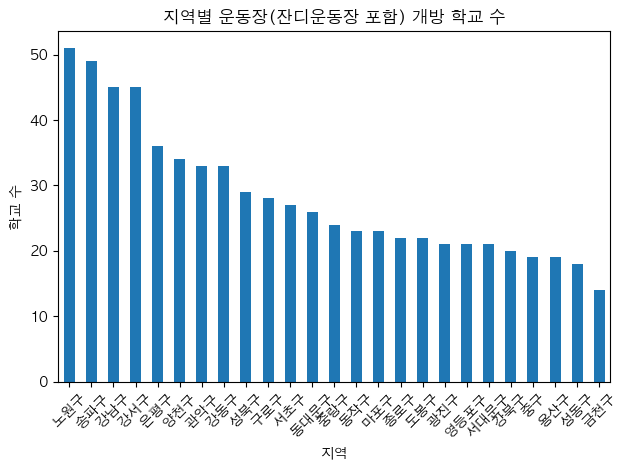

In [126]:
# 시각화
import matplotlib.pyplot as plt
# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'  # MacOS
# 지역별 학교 개수 시각화
school_counts.plot(kind='bar')
plt.title('지역별 운동장(잔디운동장 포함) 개방 학교 수')
plt.xlabel('지역')
plt.ylabel('학교 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7) 좌표(위경도) 포함한 데이터셋 반환

In [140]:
df_with_coordinates = pd.read_csv('data/서울시 중고등학교 사립_or_민간개방 공립 - 서울시 중고등학교 사립_or_민간개방 공립.csv', encoding='utf-8')
df_with_coordinates.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,Latitude,Longitude,지역
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47,37.542631,127.086825,광진구
1,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,성동구
2,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42,37.561861,127.044243,성동구
3,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,광진구
4,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,성동구


In [141]:
# 시각화
import folium
# 서울시 중심 좌표
seoul_center = [37.5665, 126.9780]
# 지도 생성
m = folium.Map(location=seoul_center, zoom_start=11)
# 학교 위치에 마커 추가
for idx, row in df_with_coordinates.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=row['학교명']
    ).add_to(m)
# 지도 저장
m.save('data/서울시 중학교 민간개방 운동장 위치 지도.html')

In [142]:
# 지도 보기
m

In [143]:
df_final = df_with_coordinates.copy()

### 6) 체육장 용지 면적이 나와있는 데이터

In [42]:
# df_size_mid = pd.read_csv('data/2025년도_학교용지 현황(중)_서울특별시교육청.csv')
# df_size_mid.head()

,시도교육청,교육지원청,지역,정보공시 학교코드,학교명,학교급코드,설립구분,제외여부,제외사유,교사대지,체육장,계,부속토지,합 계,공동사용여부,공동사용학교명,설립유형
0,서울특별시교육청,서울특별시강서양천교육지원청,서울특별시 강서구,S010000975,등촌중학교,3,사립,N,NaN,2137,6360,8497,38887,47384,×,NaN,단설
1,서울특별시교육청,서울특별시서부교육지원청,서울특별시 은평구,S010001951,영락중학교,3,사립,N,NaN,2112,4983,7095,13148,20243,×,NaN,단설
2,서울특별시교육청,서울특별시동부교육지원청,서울특별시 중랑구,S010001387,중화중학교,3,공립,N,NaN,3744,3916,7660,9615,17275,×,NaN,단설
3,서울특별시교육청,서울특별시강동송파교육지원청,서울특별시 강동구,S010000891,천호중학교,3,공립,N,NaN,4387,4050,8437,7987,16424,×,NaN,단설
4,서울특별시교육청,서울특별시동작관악교육지원청,서울특별시 동작구,S010001546,강현중학교,3,공립,N,NaN,2985,4129,7114,7767,14881,×,NaN,단설


In [43]:
# df_size_high = pd.read_csv('data/2025년도_학교용지 현황(고)_서울특별시교육청.csv')
# df_size_high.head()

,시도교육청,교육지원청,지역,정보공시 학교코드,학교명,학교급코드,설립구분,제외여부,제외사유,교사대지,체육장,계,부속토지,합 계,공동사용여부,공동사용학교명,설립유형
0,서울특별시교육청,서울특별시교육청,서울특별시 강남구,S000003540,국립국악고등학교,4,국립,N,NaN,17593,1392,18985,0,18985,○,국립국악중학교,단설
1,서울특별시교육청,서울특별시교육청,서울특별시 성북구,S000003561,서울대학교사범대학부설고등학교,4,국립,N,NaN,27076,9524,36600,0,36600,○,서울대학교사범대학부설중학교,부설
2,서울특별시교육청,서울특별시교육청,서울특별시 금천구,S000005401,국립전통예술고등학교,4,국립,N,NaN,13153,0,13153,0,13153,○,국립전통예술중학교,단설
3,서울특별시교육청,서울특별시교육청,서울특별시 송파구,S010000370,가락고등학교,4,공립,N,NaN,11026,5478,16504,0,16504,×,NaN,단설
4,서울특별시교육청,서울특별시교육청,서울특별시 강동구,S010000371,강동고등학교,4,사립,N,NaN,2177,5261,7438,904,8342,×,NaN,단설


In [44]:
# df_size = pd.concat([df_size_mid, df_size_high], ignore_index=True)
# df_size.head()

,시도교육청,교육지원청,지역,정보공시 학교코드,학교명,학교급코드,설립구분,제외여부,제외사유,교사대지,체육장,계,부속토지,합 계,공동사용여부,공동사용학교명,설립유형
0,서울특별시교육청,서울특별시강서양천교육지원청,서울특별시 강서구,S010000975,등촌중학교,3,사립,N,NaN,2137,6360,8497,38887,47384,×,NaN,단설
1,서울특별시교육청,서울특별시서부교육지원청,서울특별시 은평구,S010001951,영락중학교,3,사립,N,NaN,2112,4983,7095,13148,20243,×,NaN,단설
2,서울특별시교육청,서울특별시동부교육지원청,서울특별시 중랑구,S010001387,중화중학교,3,공립,N,NaN,3744,3916,7660,9615,17275,×,NaN,단설
3,서울특별시교육청,서울특별시강동송파교육지원청,서울특별시 강동구,S010000891,천호중학교,3,공립,N,NaN,4387,4050,8437,7987,16424,×,NaN,단설
4,서울특별시교육청,서울특별시동작관악교육지원청,서울특별시 동작구,S010001546,강현중학교,3,공립,N,NaN,2985,4129,7114,7767,14881,×,NaN,단설


In [45]:
# # '시도교육청', '교육지원청', '지역', '학교명', '설립구분', '체육장', '공동사용여부', '공동사용학교명' 컬럼만 남기기
# df_size = df_size[['시도교육청', '교육지원청', '지역', '학교명', '설립구분', '체육장', '공동사용여부', '공동사용학교명']]
# df_size.head()

,시도교육청,교육지원청,지역,학교명,설립구분,체육장,공동사용여부,공동사용학교명
0,서울특별시교육청,서울특별시강서양천교육지원청,서울특별시 강서구,등촌중학교,사립,6360,×,NaN
1,서울특별시교육청,서울특별시서부교육지원청,서울특별시 은평구,영락중학교,사립,4983,×,NaN
2,서울특별시교육청,서울특별시동부교육지원청,서울특별시 중랑구,중화중학교,공립,3916,×,NaN
3,서울특별시교육청,서울특별시강동송파교육지원청,서울특별시 강동구,천호중학교,공립,4050,×,NaN
4,서울특별시교육청,서울특별시동작관악교육지원청,서울특별시 동작구,강현중학교,공립,4129,×,NaN


In [46]:
# # df_with_coordinates와 df_size를 학교명 기준으로 병합
# # 겹치는 컬럼은 설립구분, 지역이므로 왼쪽으로 병합
# df_final = pd.merge(df_with_coordinates, df_size, on='학교명', how='left', suffixes=('_x', '_y'))
# df_final.info()
# df_final.head()


<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   학교종류명      180 non-null    str    
 1   설립구분_x     180 non-null    str    
 2   학교명        180 non-null    str    
 3   관할조직명      180 non-null    str    
 4   도로명주소      180 non-null    str    
 5   Latitude   180 non-null    float64
 6   Longitude  180 non-null    float64
 7   시도교육청_x    180 non-null    str    
 8   교육지원청_x    180 non-null    str    
 9   지역_x       180 non-null    str    
 10  운동장 개방여부   180 non-null    str    
 11  시도교육청_y    179 non-null    str    
 12  교육지원청_y    179 non-null    str    
 13  지역_y       179 non-null    str    
 14  설립구분_y     179 non-null    str    
 15  체육장        179 non-null    float64
 16  공동사용여부     179 non-null    str    
 17  공동사용학교명    7 non-null      str    
dtypes: float64(3), str(15)
memory usage: 25.4 KB


,학교종류명,설립구분_x,학교명,관할조직명,도로명주소,Latitude,Longitude,시도교육청_x,교육지원청_x,지역_x,운동장 개방여부,시도교육청_y,교육지원청_y,지역_y,설립구분_y,체육장,공동사용여부,공동사용학교명
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,6117.0,×,NaN
1,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,7240.0,×,NaN
2,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,7004.0,×,NaN
3,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,0.0,○,무학여자고등학교
4,중학교,공립,광진중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로64길 45,37.531786,127.089619,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,4968.0,×,NaN


In [47]:
# # 체육장 공동사용 학교 추출
# joint_use = df_final[df_final['공동사용여부'] == '○']
# print(joint_use[['학교명', '공동사용학교명']])

        학교명    공동사용학교명
3     무학중학교   무학여자고등학교
8    영등포중학교    영등포고등학교
20   해누리중학교  서울해누리초등학교
33    길음중학교   서울길음초등학교
75    청운중학교   경기상업고등학교
98    노일중학교    서울노일유치원
147  효문고등학교      효문중학교


공동사용하는 학교가 동시에 등록되어 있지 않음 → 두 학교 중 한 곳을 사용한다고 가정

In [48]:
# # 초등학교와 공동사용하는 중학교는 원본데이터에서 제거
# # 공동사용학교명에 '초등학교'가 포함된 학교명 추출
# joint_use_with_elementary = joint_use[joint_use['공동사용학교명'].str.contains('초등학교', na=False)]
# print(joint_use_with_elementary[['학교명', '공동사용학교명']])
# # df_final에서 공동사용학교명에 '초등학교'가 포함된 학교명 제거
# df_final = df_final[~df_final['공동사용학교명'].str.contains('초등학교', na=False)]


       학교명    공동사용학교명
20  해누리중학교  서울해누리초등학교
33   길음중학교   서울길음초등학교


In [49]:
# # 체육장이 0인 학교 필터링
# df_final_no_gym = df_final[df_final['체육장'] == 0]\
# # 체육장이 0인 학교 개수 확인
# no_gym_count = df_final_no_gym.shape[0]
# print(f"체육장이 0인 학교 수: {no_gym_count}")
# # 이름 확인
# print(df_final_no_gym['학교명'])

# # 해당 학교의 공동사용 학교 확인
# for idx, row in df_final_no_gym.iterrows():
#     print(f"학교명: {row['학교명']}, 공동사용여부: {row['공동사용여부']}, 공동사용학교명: {row['공동사용학교명']}")



체육장이 0인 학교 수: 3
3      무학중학교
8     영등포중학교
75     청운중학교
Name: 학교명, dtype: str
학교명: 무학중학교, 공동사용여부: ○, 공동사용학교명: 무학여자고등학교
학교명: 영등포중학교, 공동사용여부: ○, 공동사용학교명: 영등포고등학교
학교명: 청운중학교, 공동사용여부: ○, 공동사용학교명: 경기상업고등학교


In [50]:
# df_final.head()

,학교종류명,설립구분_x,학교명,관할조직명,도로명주소,Latitude,Longitude,시도교육청_x,교육지원청_x,지역_x,운동장 개방여부,시도교육청_y,교육지원청_y,지역_y,설립구분_y,체육장,공동사용여부,공동사용학교명
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,6117.0,×,NaN
1,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,7240.0,×,NaN
2,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,7004.0,×,NaN
3,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 성동구,공립,0.0,○,무학여자고등학교
4,중학교,공립,광진중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로64길 45,37.531786,127.089619,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,서울특별시교육청,서울특별시성동광진교육지원청,서울특별시 광진구,공립,4968.0,×,NaN


In [51]:
# # 체육장이 0인 학교의 실제 체육장 크기를 확인하기 위해 고등학교 정보 불러오기
# df_size_high.head()
# # '무학여자고등학교', '영등포고등학교', '서울길음초등학교', '경기상업고등학교'의 체육장 크기 확인하여 체육장이 0인 학교의 실제 체육장 크기 추정
# schools_to_check = ['무학여자고등학교', '영등포고등학교', '경기상업고등학교']
# for school in schools_to_check:
#     gym_size = df_size_high[df_size_high['학교명'] == school]['체육장'].values
#     if len(gym_size) > 0:
#         print(f"{school}의 체육장 크기: {gym_size[0]}")

# # 해당 값을 df_final의 체육장 크기로 대체
# # 무학여자고등학교 체육장 크기로 대체
# df_final.loc[df_final['학교명'] == '무학중학교', '체육장'] = df_size_high[df_size_high['학교명'] == '무학여자고등학교']['체육장'].values[0]
# # 영등포고등학교 체육장 크기로 대체
# df_final.loc[df_final['학교명'] == '영등포중학교', '체육장'] = df_size_high[df_size_high['학교명'] == '영등포고등학교']['체육장'].values[0]
# # 경기상업고등학교 체육장 크기로 대체
# df_final.loc[df_final['학교명'] == '청운중학교', '체육장'] = df_size_high[df_size_high['학교명'] == '경기상업고등학교']['체육장'].values[0]

# # 체육장이 0인 학교 개수 다시 확인
# no_gym_count_final = df_final[df_final['체육장'] == 0].shape[0]
# print(f"체육장이 0인 학교 수 (최종 업데이트 후): {no_gym_count_final}")
# # 체육장이 0인 학교의 공동사용 학교명 확인
# for idx, row in df_final[df_final['체육장'] == 0].iterrows():
#     print(f"학교명: {row['학교명']}, 공동사용여부: {row['공동사용여부']}, 공동사용학교명: {row['공동사용학교명']}")



무학여자고등학교의 체육장 크기: 11290
영등포고등학교의 체육장 크기: 7725
경기상업고등학교의 체육장 크기: 11542
체육장이 0인 학교 수 (최종 업데이트 후): 0


In [52]:
# # 지역_y, 설립구분_y 삭제
# df_final = df_final.drop(columns=['지역_y', '설립구분_y'])

# # 지역_x → 지역, 설립구분_x → 설립구분으로 컬럼명 변경
# df_final = df_final.rename(columns={'지역_x': '지역', '설립구분_x': '설립구분'})

# # 필요한 컬럼만 저장
# df_final = df_final[['학교종류명', '설립구분', '학교명', '관할조직명', '도로명주소', 'Latitude', 'Longitude', '시도교육청_x', '교육지원청_x', '지역', '운동장 개방여부', '체육장', '공동사용여부', '공동사용학교명']]

# # 컬럼명 변경
# df_final = df_final.rename(columns={'Longitude': '경도', 'Latitude': '위도', '시도교육청_x': '시도교육청', '교육지원청_x': '교육지원청'})

In [53]:
# # csv 파일로 저장
# df_final.to_csv('data/서울시 중고학교 민간개방 운동장 정보_체육장 크기 업데이트.csv', index=False, encoding='cp949')
# df_final.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,위도,경도,시도교육청,교육지원청,지역,운동장 개방여부,체육장,공동사용여부,공동사용학교명
0,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,6117.0,×,NaN
1,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,7240.0,×,NaN
2,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,7004.0,×,NaN
3,중학교,공립,무학중학교,서울특별시성동광진교육지원청,서울특별시 성동구 행당로 120,37.557399,127.032868,서울특별시교육청,서울특별시성동광진교육지원청,성동구,유,11290.0,○,무학여자고등학교
4,중학교,공립,광진중학교,서울특별시성동광진교육지원청,서울특별시 광진구 뚝섬로64길 45,37.531786,127.089619,서울특별시교육청,서울특별시성동광진교육지원청,광진구,유,4968.0,×,NaN


In [54]:
# df_final.info()

<class 'pandas.DataFrame'>
Index: 178 entries, 0 to 179
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   학교종류명     178 non-null    str    
 1   설립구분      178 non-null    str    
 2   학교명       178 non-null    str    
 3   관할조직명     178 non-null    str    
 4   도로명주소     178 non-null    str    
 5   위도        178 non-null    float64
 6   경도        178 non-null    float64
 7   시도교육청     178 non-null    str    
 8   교육지원청     178 non-null    str    
 9   지역        178 non-null    str    
 10  운동장 개방여부  178 non-null    str    
 11  체육장       177 non-null    float64
 12  공동사용여부    177 non-null    str    
 13  공동사용학교명   5 non-null      str    
dtypes: float64(3), str(11)
memory usage: 20.9 KB


## 3) 200m 이내에 초등학교/유치원이 있는 경우 제거하기

1. 전국초중등학교위치정보 데이터 전처리

In [ ]:
# df_ele = pd.read_csv('data/전국초중등학교위치표준데이터.csv', encoding='cp949')
# df_ele.head()

In [ ]:
# # '소재지도로명주소' 컬럼에 '서울특별시' 들어가는 행 추출
# df_ele_seoul = df_ele[df_ele['소재지도로명주소'].str.contains('서울특별시', na=False)]
# df_ele_seoul.head()

In [ ]:
# # 중복값 및 결측치 확인
# print('중복행 개수: \n', df_ele_seoul.duplicated().sum())
# print('---------------')
# print('컬럼별 결측치 개수: \n', df_ele_seoul.isnull().sum())

In [58]:
# # 초등학교만 추출
# df_ele_seoul = df_ele_seoul[df_ele_seoul['학교급구분'] == '초등학교']

In [59]:
# # 필요한 컬럼만 추출
# df_ele_seoul = df_ele_seoul[['학교명', '위도', '경도']]

2) 어린이집유치원좌표정보 데이터 전처리

In [ ]:
# df_kin = pd.read_csv('data/어린이집유치원좌표정보.csv')
# df_kin.head()

In [ ]:
# # 어린이집 제거
# df_young = df_kin[df_kin['시설명'].str.contains('어린이집', na=False)]

# # 해당 데이터에 포함되어 있는 어린이집 개수 출력
# print(f"어린이집 개수: {df_young.shape[0]}")

# df_kin = df_kin[~df_kin['시설명'].str.contains('어린이집', na=False)]
# df_kin.head()

In [ ]:
# df_kin.info()

In [ ]:
# # 시설위치에 '서울특별시'가 들어있는 경우만 추출
# df_kin_seoul = df_kin[df_kin['시설위치'].str.contains('서울특별시', na=False)]
# df_kin_seoul.head()

In [ ]:
# df_kin_seoul.info()

In [65]:
# # 필요한 컬럼만 추출
# df_kin_seoul = df_kin_seoul[['시설명', '위도', '경도']]

3. 유치원 데이터와 초등학교 데이터 결합

In [ ]:
# # 유치원 데이터와 초등학교 데이터 결합
# df_combined = pd.concat([df_ele_seoul.rename(columns={'학교명': '시설명'}), df_kin_seoul], ignore_index=True)
# df_combined.head()

후보지 ⟷ 초등학교/유치원 거리 matrix 구하기

In [ ]:
# # 후보지 데이터 준비
# df_candidate = df_final.copy()
# df_candidate = df_candidate[['학교명', '위도', '경도']]
# df_candidate.rename(columns={'학교명': '시설명'}, inplace=True)

# df_candidate.head()

In [ ]:
# # 초등학교/유치원 데이터 준비
# df_restricted = df_combined.copy()
# df_restricted.head()

In [69]:
# # 거리 함수 정의(지구를 타원체라고 정의한 후 직선거리 구하는 함수 사용)
# from geopy.distance import geodesic

# def get_distance(lat1, lon1, lat2, lon2):
#     return geodesic((lat1, lon1), (lat2, lon2)).meters

In [70]:
# # 각 후보지에 대해 최소 거리 계산
# def min_distance_to_restricted(row, df_restricted):
#     distances = df_restricted.apply(
#         lambda x: get_distance(row['위도'], row['경도'],
#                                x['위도'], x['경도']),
#                                axis=1
#     )
#     return distances.min()
# df_candidate['min_dist'] = df_candidate.apply(
#     lambda row: min_distance_to_restricted(row, df_restricted), axis=1
# )

In [ ]:
# df_candidate.head()

In [ ]:
# df_candidate.info()

In [ ]:
# # 200m 이내에 초등학교/유치원이 존재하는 후보지는 제거
# df_candidate_filtered = df_candidate[df_candidate['min_dist'] >= 200]

# # 200m 이내에 초등학교/유치원이 존재하는 후보지 개수 및 시설명 확인
# filtered_count = df_candidate_filtered.shape[0]
# print(f"200m 이내에 초등학교/유치원이 존재하는 후보지 개수: {filtered_count}")

In [ ]:
# # 최종 후보지
# final_candidates = df_candidate_filtered[['시설명', '위도', '경도']]
# final_candidates.head()

In [75]:
# # 최종 후보지에 해당하는 시설명을 기반으로 df_final에서 필터링하기
# final_candidate_details = df_final[df_final['학교명'].isin(final_candidates['시설명'])]
# # 최종 후보지 상세 정보 csv 파일로 저장
# final_candidate_details.to_csv('data/final_candidates.csv', index=False, encoding='cp949')

In [ ]:
# final_candidate_details.head()

In [ ]:
# final_candidate_details.info()

In [ ]:
# # 최종적으로 선정된 후보지 중 중학교/고등학교 개수 시각화
# import matplotlib.pyplot as plt
# # 한글 폰트 깨짐 방지
# plt.rcParams['font.family'] = 'AppleGothic'  # MacOS
# # 학교 종류별 개수 계산
# school_type_counts = final_candidate_details['학교종류명'].value_counts()
# # 시각화
# school_type_counts.plot(kind='bar')
# plt.title('최종 후보지 학교 종류별 개수')
# plt.xlabel('학교 종류')
# plt.ylabel('학교 수')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


In [ ]:
# # 구별 후보지 개수 시각화
# # 구별 후보지 개수 계산
# district_counts = final_candidate_details['지역'].value_counts()
# # 시각화
# district_counts.plot(kind='bar')
# plt.title('최종 후보지 구별 개수')
# plt.xlabel('구')
# plt.ylabel('학교 수')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # 표로 보여주기
# final_candidate_details['지역'].value_counts()

In [ ]:
# # 지도에 보여주기
# import folium
# # 서울시 중심 좌표
# seoul_center = [37.5665, 126.9780]
# # 지도 생성
# m = folium.Map(location=seoul_center, zoom_start=11)
# # 학교 위치에 마커 추가
# for idx, row in final_candidate_details.iterrows():
#     folium.Marker(
#         location=[row['위도'], row['경도']],
#         popup=row['학교명']
#     ).add_to(m)
# # 지도 저장
# m.save('data/final_candidates_map.html')
# # 지도 보기
# m

In [ ]:
# # 수요지와 후보지를 한 지도에 보여주기
# df_demand = pd.read_csv('data/아파트별_수요.csv')

# import folium

# m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)
# for _, row in df_demand.iterrows():
#     folium.CircleMarker(
#         location=[row['Latitude'], row['Longitude']],
#         radius=max(2, row['수요']**0.5),  # 🔥 핵심 (크기 조절)
#         color='blue',
#         fill=True,
#         fill_opacity=0.5,
#         popup=f"수요: {row['수요']:.1f}"
#     ).add_to(m)
# for _, row in final_candidate_details.iterrows():
#     folium.Marker(
#         location=[row['위도'], row['경도']],
#         popup=row['학교명'],
#         icon=folium.Icon(color='red', icon='info-sign')
#     ).add_to(m)
# m.save('data/demand_and_candidates_map.html')
# m

In [ ]:
# df_demand.info()

## 3) 기숙사 있는 학교 제거

In [144]:
# 데이터 불러오기
df_dorm = pd.read_csv('data/서울시 학교별 학생교육활동에 필요한 지원시설 현황.csv', encoding='cp949')
df_dorm.head()

,시도교육청,시도교육청코드,교육지원청,교육지원청코드,지역,지역코드,소재지구분코드,정보공시 학교코드,학교명,학교급코드,...,체육관,강당,기숙사 재실인원,수영장,진로 상담실,설립유형,설립유형코드,학교과정구분값(2-3-4),학교과정구분명(초-중-고),공시연도
0,서울특별시교육청,A000000001,교육부,A000000001,서울특별시 서초구,1.165011e+09,1,S000003511,서울교육대학교부설초등학교,2,...,1.0,1.0,NaN,NaN,NaN,부설,4,NaN,NaN,2021
1,서울특별시교육청,A000000001,교육부,A000000001,서울특별시 종로구,1.111017e+09,1,S000003563,서울대학교사범대학부설초등학교,2,...,1.0,1.0,NaN,NaN,1.0,부설,4,2,초,2021
2,서울특별시교육청,B100000001,서울특별시강남서초교육지원청,B100000249,서울특별시 강남구,1.168010e+09,1,S010000738,서울개일초등학교,2,...,NaN,1.0,NaN,NaN,1.0,단설,1,2,초,2021
3,서울특별시교육청,B100000001,서울특별시강남서초교육지원청,B100000249,서울특별시 강남구,1.168010e+09,1,S010000741,서울구룡초등학교,2,...,1.0,NaN,NaN,NaN,NaN,단설,1,NaN,NaN,2021
4,서울특별시교육청,B100000001,서울특별시강남서초교육지원청,B100000249,서울특별시 강남구,1.168011e+09,1,S010000742,서울논현초등학교,2,...,1.0,NaN,NaN,1.0,NaN,단설,1,NaN,NaN,2021


In [145]:
# 기숙사재실인원=NaN이 아닌 학교만 추출
df_dorm_filtered = df_dorm[df_dorm['기숙사 재실인원'].notna()]
# df_final에서 df_dorm_filtered의 학교명과 일치하는 학교명 추출
df_final_dorm = df_final[df_final['학교명'].isin(df_dorm_filtered['학교명'])]
# df_final에서 df_dorm_filtered의 학교 제거
df_final_no_dorm = df_final[~df_final['학교명'].isin(df_dorm_filtered['학교명'])]
df_final_no_dorm.head()

,학교종류명,설립구분,학교명,관할조직명,도로명주소,Latitude,Longitude,지역
0,중학교,사립,동국대학교사범대학부속가람중학교,서울특별시성동광진교육지원청,서울특별시 광진구 광나루로36길 47,37.542631,127.086825,광진구
1,중학교,공립,행당중학교,서울특별시성동광진교육지원청,서울특별시 성동구 왕십리로 189,37.554293,127.042261,성동구
2,중학교,사립,한양대학교사범대학부속중학교,서울특별시성동광진교육지원청,서울특별시 성동구 마조로 42,37.561861,127.044243,성동구
3,중학교,공립,신양중학교,서울특별시성동광진교육지원청,서울특별시 광진구 자양강변길 73,37.533301,127.063455,광진구
4,중학교,공립,성원중학교,서울특별시성동광진교육지원청,서울특별시 성동구 성덕정9가길 13,37.539213,127.052142,성동구


In [146]:
df_final_no_dorm.info()

<class 'pandas.DataFrame'>
Index: 430 entries, 0 to 488
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   학교종류명      430 non-null    str    
 1   설립구분       430 non-null    str    
 2   학교명        430 non-null    str    
 3   관할조직명      430 non-null    str    
 4   도로명주소      430 non-null    str    
 5   Latitude   430 non-null    float64
 6   Longitude  430 non-null    float64
 7   지역         430 non-null    str    
dtypes: float64(2), str(6)
memory usage: 30.2 KB


In [147]:
df_final_dorm.info()

<class 'pandas.DataFrame'>
Index: 59 entries, 11 to 480
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   학교종류명      59 non-null     str    
 1   설립구분       59 non-null     str    
 2   학교명        59 non-null     str    
 3   관할조직명      59 non-null     str    
 4   도로명주소      59 non-null     str    
 5   Latitude   59 non-null     float64
 6   Longitude  59 non-null     float64
 7   지역         59 non-null     str    
dtypes: float64(2), str(6)
memory usage: 4.1 KB


In [149]:
# df_final_dorm to csv
df_final_no_dorm.to_csv('data/final_candidates.csv', index=False, encoding='cp949')

In [150]:
# df_final_no_dorm 중학교/고등학교/공립/사립 개수 구해서 표로 보여주기
# 중학교 중 공립 개수
num_mid_public_no_dorm = df_final_no_dorm[(df_final_no_dorm['학교종류명'] == '중학교') & (df_final_no_dorm['설립구분'] == '공립')].shape[0]
print(f'중학교 공립 개수: {num_mid_public_no_dorm}')
# 중학교 중 사립 개수
num_mid_private_no_dorm = df_final_no_dorm[(df_final_no_dorm['학교종류명'] == '중학교') & (df_final_no_dorm['설립구분'] == '사립')].shape[0]
print(f'중학교 사립 개수: {num_mid_private_no_dorm}')
# 고등학교 중 공립 개수
num_high_public_no_dorm = df_final_no_dorm[(df_final_no_dorm['학교종류명'] == '고등학교') & (df_final_no_dorm['설립구분'] == '공립')].shape[0]
print(f'고등학교 공립 개수: {num_high_public_no_dorm}')
# 고등학교 중 사립 개수
num_high_private_no_dorm = df_final_no_dorm[(df_final_no_dorm['학교종류명'] == '고등학교') & (df_final_no_dorm['설립구분'] == '사립')].shape[0]
print(f'고등학교 사립 개수: {num_high_private_no_dorm}')

중학교 공립 개수: 134
중학교 사립 개수: 105
고등학교 공립 개수: 41
고등학교 사립 개수: 150


지역
노원구     40
강서구     36
강남구     27
송파구     25
양천구     24
은평구     24
성북구     23
관악구     20
강동구     20
구로구     19
동대문구    16
중구      14
종로구     14
마포구     14
광진구     13
용산구     13
도봉구     13
서대문구    13
중랑구     13
강북구     11
동작구     10
서초구     10
금천구      8
영등포구     6
성동구      4
Name: count, dtype: int64


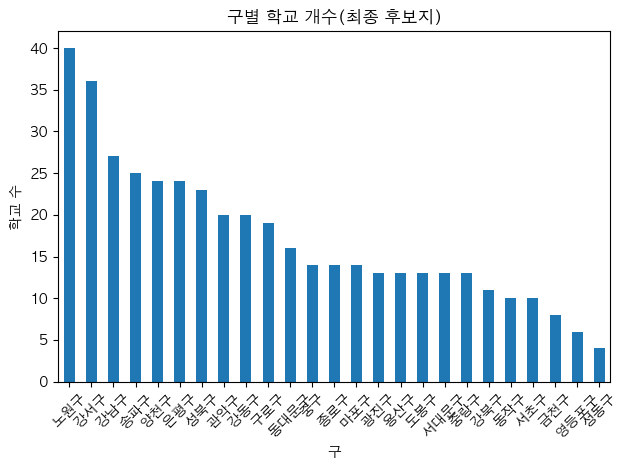

In [174]:
# 구별 학교 개수 구해서 시각화
import matplotlib.pyplot as plt
# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'  # MacOS
# 구별 학교 개수 계산
district_counts_no_dorm = df_final_no_dorm['지역'].value_counts()
# 결과 보여주기
print(district_counts_no_dorm)
# 시각화
district_counts_no_dorm.plot(kind='bar')
plt.title('구별 학교 개수(최종 후보지)')
plt.xlabel('구')
plt.ylabel('학교 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [172]:
import folium
from folium.plugins import MarkerCluster

# 서울 중심
seoul_center = [37.5665, 126.9780]

m = folium.Map(
    location=seoul_center,
    zoom_start=11,
    tiles="CartoDB positron"
)

# 제목
title_html = """
<h3 align="center" style="font-size:20px"><b>서울시 MFC 후보지 (구별 클러스터)</b></h3>
"""
m.get_root().html.add_child(folium.Element(title_html))

# 구 목록
districts = df_final_no_dorm['지역'].unique()

# 구별로 FeatureGroup + Cluster 생성
for district in districts:
    
    df_temp = df_final_no_dorm[df_final_no_dorm['지역'] == district]
    
    # 레이어 그룹
    fg = folium.FeatureGroup(name=district)
    
    # 해당 구 전용 클러스터
    marker_cluster = MarkerCluster().add_to(fg)

    for _, row in df_temp.iterrows():
        
        popup_html = f"""
        <div style="width:180px">
            <h4>{row['학교명']}</h4>
            <b>지역</b>: {row['지역']}<br>
        </div>
        """

        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=6,
            color="#d62728",
            fill=True,
            fill_color="#ff6b6b",
            fill_opacity=0.8,
            popup=folium.Popup(popup_html, max_width=220),
            tooltip=row['학교명']
        ).add_to(marker_cluster)

    fg.add_to(m)

# 레이어 컨트롤 (핵심🔥)
folium.LayerControl(collapsed=False).add_to(m)

m.save("data/map_by_district.html")

In [173]:
m